In [12]:
# [Initialization - Disable Warnings]
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

from transformers import logging
logging.set_verbosity_error()

import datasets
datasets.disable_progress_bar()
datasets.logging.set_verbosity_error()

# [Imports]
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, classification_report
from huggingface_hub import HfApi, login

## [Task 1] Dataset Preparation - Jigsaw Toxic Comments

In [1]:
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer

C:\Users\ws-\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
dataset = load_dataset("mat55555/jigsaw_toxic_comment")
dataset = dataset['train'].train_test_split(test_size=0.4, seed=42)
test_val = dataset['test'].train_test_split(test_size=0.5, seed=42)

# Create final dataset with all three splits
dataset = DatasetDict({
    'train': dataset['train'],
    'validation': test_val['train'],
    'test': test_val['test']
})

In [3]:
dataset = dataset.remove_columns(['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'])
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 95742
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 31914
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 31915
    })
})

In [4]:
dataset['train'][0]

{'text': '"\n\n Use of German Wikipedia Entry as a ""See Also"" \n\nIt should be considered bad form to ask the user to reference another language edition of Wikipedia for more information, can anyone correct this?   "',
 'label': 0}

In [5]:
dataset['train'][1]

{'text': "You're still a bunch of niggers.  173.71.78.250   Shoopsywoopsy.\n\nAnd, PS, I will edit my own talk page as I see fit, you cuntheads.",
 'label': 1}

In [6]:
#dataset = dataset.rename_column("toxic", "labels")

# Tokenization
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_ds = dataset.map(tokenize_fn, batched=True)
tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 31915/31915 [00:04<00:00, 7666.10 examples/s]


In [7]:
tokenized_ds['train'][0]["input_ids"]

tensor([  101,  1000,  2224,  1997,  2446, 16948,  4443,  2004,  1037,  1000,
         1000,  2156,  2036,  1000,  1000,  2009,  2323,  2022,  2641,  2919,
         2433,  2000,  3198,  1996,  5310,  2000,  4431,  2178,  2653,  3179,
         1997, 16948,  2005,  2062,  2592,  1010,  2064,  3087,  6149,  2023,
         1029,  1000,   102,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0])

In [8]:
tokenizer.decode(tokenized_ds["train"][0]["input_ids"])

'[CLS] " use of german wikipedia entry as a " " see also " " it should be considered bad form to ask the user to reference another language edition of wikipedia for more information, can anyone correct this? " [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

## [Task 2] Odd/Even Layer Distillation

In [9]:
from transformers import BertForSequenceClassification, BertConfig

# Teacher model
teacher = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
# Student models
def create_student():
    config = BertConfig.from_pretrained("bert-base-uncased")
    config.num_hidden_layers = 6
    return BertForSequenceClassification(config)

student_odd = create_student()
student_even = create_student()

# Layer transfer functions
def transfer_layers(src_model, dest_model, layer_indices):
    for dest_idx, src_idx in enumerate(layer_indices):
        dest_model.bert.encoder.layer[dest_idx].load_state_dict(
            src_model.bert.encoder.layer[src_idx].state_dict()
        )
    return dest_model

In [11]:
# Copy layers (0-based indices)
transfer_layers(teacher, student_odd, [0,2,4,6,8,10])   # Original layers 1,3,5,7,9,11
transfer_layers(teacher, student_even, [1,3,5,7,9,11])  # Original layers 2,4,6,8,10,12

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-1

In [13]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Teacher Model Trainable Parameters: {count_trainable_parameters(teacher)}")
print(f"Student Odd-Layer Model Trainable Parameters: {count_trainable_parameters(student_odd)}")
print(f"Student Even-Layer Model Trainable Parameters: {count_trainable_parameters(student_even)}")

Teacher Model Trainable Parameters: 109483778
Student Odd-Layer Model Trainable Parameters: 66956546
Student Even-Layer Model Trainable Parameters: 66956546


## [Task 3] LoRA Implementation

In [14]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query", "value"],
    lora_dropout=0.05,
    bias="none",
    modules_to_save=["classifier"]
)

student_lora = create_student()
lora_model = get_peft_model(student_lora, lora_config)
lora_model.print_trainable_parameters()

trainable params: 296,450 || all params: 67,252,996 || trainable%: 0.4408


## [Task 4] Training and Evaluation

In [15]:
import torch
import numpy as np
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from transformers import AdamW, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score
from peft import PeftModel

In [16]:
def train_model(model, model_name, train_data, val_data, num_epochs=5, batch_size=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    # DataLoaders
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size)
    
    # Optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
    
    # Metrics storage
    metrics = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_f1 = 0
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_loss = 0
        for batch in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('label')
            outputs = model(**batch, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(train_loader)
        metrics['train_loss'].append(avg_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                labels = batch.pop('label')
                outputs = model(**batch, labels=labels)
                val_loss += outputs.loss.item()
                logits = outputs.logits
                preds = torch.argmax(logits, dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        val_f1 = f1_score(all_labels, all_preds, average='binary')
        
        metrics['val_loss'].append(avg_val_loss)
        metrics['val_acc'].append(val_acc)
        metrics['val_f1'].append(val_f1)
        
        # Save best model based on validation F1-score
        if val_f1 > best_f1:
            best_f1 = val_f1
            if isinstance(model, PeftModel):
                merged_model = model.merge_and_unload()
                merged_model.save_pretrained(f"{model_name}_best")
            else:
                model.save_pretrained(f"{model_name}_best")
            tokenizer.save_pretrained(f"{model_name}_best")
        
        print(f"{model_name} Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}")
    
    return metrics

In [17]:
# Train all models
all_metrics = {
    "Odd-Layer": train_model(student_odd, "Odd-Layer", tokenized_ds['train'], tokenized_ds['validation']),
    "Even-Layer": train_model(student_even, "Even-Layer", tokenized_ds['train'], tokenized_ds['validation']),
    "LoRA": train_model(lora_model, "LoRA", tokenized_ds['train'], tokenized_ds['validation'])
}

Odd-Layer Epoch 1:   0%|          | 0/5984 [00:00<?, ?it/s]

[2025-03-19 03:07:22,498] [INFO] [real_accelerator.py:222:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/opt/tljh/user/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/opt/tljh/user/compiler_compat/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Odd-Layer Epoch 1: Train Loss=0.1539, Val Loss=0.1231, Val Acc=0.9581, Val F1=0.7956


Odd-Layer Epoch 2:   0%|          | 0/5984 [00:00<?, ?it/s]

...

LoRA Epoch 3: Train Loss=0.2328, Val Loss=0.2275, Val Acc=0.9210, Val F1=0.4514


LoRA Epoch 4:   0%|          | 0/5984 [00:00<?, ?it/s]

LoRA Epoch 4: Train Loss=0.2319, Val Loss=0.2276, Val Acc=0.9210, Val F1=0.4484


LoRA Epoch 5:   0%|          | 0/5984 [00:00<?, ?it/s]

LoRA Epoch 5: Train Loss=0.2321, Val Loss=0.2271, Val Acc=0.9211, Val F1=0.4522


In [20]:
def evaluate_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('label')
            outputs = model(**batch, labels=labels)
            total_loss += outputs.loss.item()
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average='binary')
    return {'loss': avg_loss, 'accuracy': accuracy, 'f1': f1}

Odd-Layer Test Metrics: Loss=0.1166, Accuracy=0.9613, F1-Score=0.7979
Even-Layer Test Metrics: Loss=0.1174, Accuracy=0.9557, F1-Score=0.7869
LoRA Test Metrics: Loss=0.2258, Accuracy=0.9228, F1-Score=0.4621


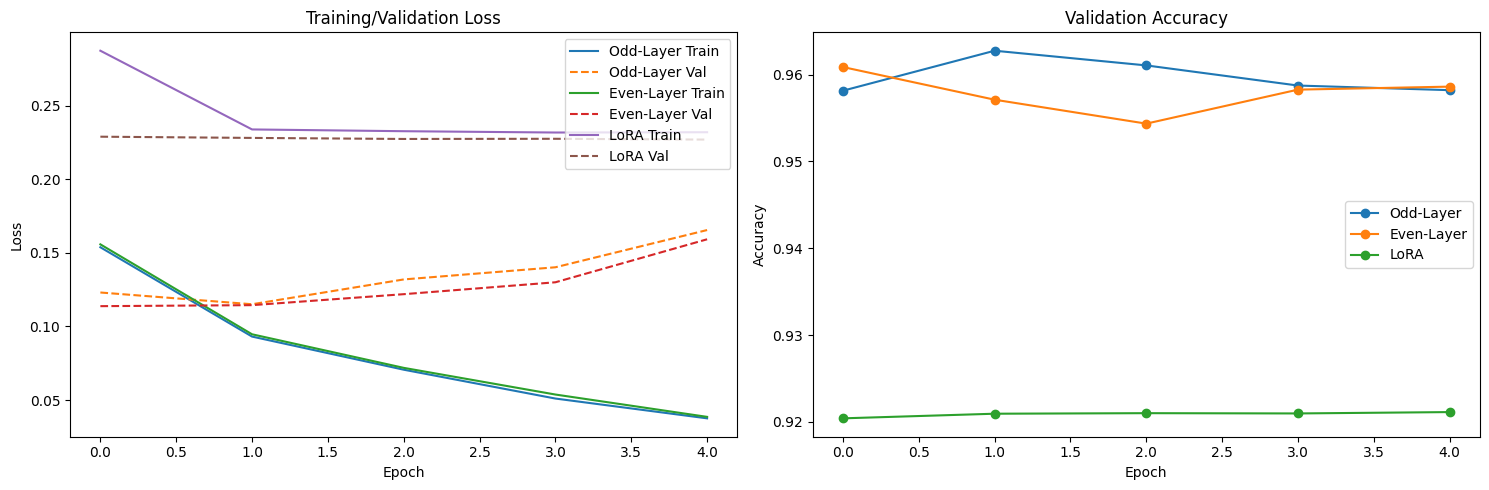

In [27]:
# [Plotting Function]
def plot_metrics(metrics_dict):
    plt.figure(figsize=(15, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    for name, metrics in metrics_dict.items():
        plt.plot(metrics['train_loss'], label=f'{name} Train')
        plt.plot(metrics['val_loss'], '--', label=f'{name} Val')
    plt.title('Training/Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy Plot
    plt.subplot(1, 2, 2)
    for name, metrics in metrics_dict.items():
        plt.plot(metrics['val_acc'], '-o', label=name)
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Generate plots
plot_metrics(all_metrics)

In [28]:
# Evaluate best models on test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loader = DataLoader(tokenized_ds['test'], batch_size=16)

for model_name in ["Odd-Layer", "Even-Layer", "LoRA"]:
    best_model = BertForSequenceClassification.from_pretrained(f"{model_name}_best")
    best_model.to(device)
    test_metrics = evaluate_model(best_model, test_loader, device)
    print(f"{model_name} Test Metrics: Loss={test_metrics['loss']:.4f}, Accuracy={test_metrics['accuracy']:.4f}, F1-Score={test_metrics['f1']:.4f}")

Odd-Layer Test Metrics: Loss=0.1166, Accuracy=0.9613, F1-Score=0.7979
Even-Layer Test Metrics: Loss=0.1174, Accuracy=0.9557, F1-Score=0.7869
LoRA Test Metrics: Loss=0.2258, Accuracy=0.9228, F1-Score=0.4621
